<a href="https://colab.research.google.com/github/24ume096-star/Hactoberfest2022/blob/main/Copy_of_Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
\\\\\pip install pandas numpy scikit-learn matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


In [ ]:
from google.colab import files
uploaded = files.upload()
# Load dataset (replace filename if needed)
data = pd.read_excel('Forging_Pressure_Dataset.xlsx')
data.describe()

Saving Forging_Pressure_Dataset.xlsx to Forging_Pressure_Dataset (1).xlsx


,h0_mm,hf_mm,diameter_mm,flow_stress_MPa,friction,forging_pressure_MPa
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,54.720400,37.411600,77.49780,223.966100,0.223500,301.457500
std,13.799859,10.766164,18.78076,44.669035,0.040982,76.168508
min,30.440000,17.180000,48.14000,151.490000,0.160000,180.980000
25%,44.420000,28.800000,60.16250,186.250000,0.190000,240.465000
50%,52.365000,36.280000,73.82500,223.035000,0.220000,293.095000
75%,66.205000,44.887500,95.17250,264.815000,0.260000,342.645000
max,79.740000,66.380000,119.40000,298.140000,0.300000,559.120000


In [ ]:
data.columns = ['h_in_mm','h_out_mm','diameter_mm','flow_stress_Mpa','friction','forging_pressure_MPa']
# Convert to numeric, coercing errors to NaN
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.head()

,h_in_mm,h_out_mm,diameter_mm,flow_stress_Mpa,friction,forging_pressure_MPa
0,40.56,33.80,74.71,295.41,0.25,403.26
1,44.43,30.82,95.24,267.90,0.25,407.09
2,51.54,40.61,48.14,173.36,0.16,194.76
3,44.70,36.33,49.91,185.59,0.22,221.89
4,66.22,47.25,98.95,257.44,0.22,334.87


Correlation Matrix:
                       h_in_mm  h_out_mm  diameter_mm  flow_stress_Mpa  \
h_in_mm               1.000000  0.871808    -0.146108        -0.096597   
h_out_mm              0.871808  1.000000    -0.236264        -0.049009   
diameter_mm          -0.146108 -0.236264     1.000000        -0.049881   
flow_stress_Mpa      -0.096597 -0.049009    -0.049881         1.000000   
friction             -0.037870 -0.050248    -0.058444        -0.088687   
forging_pressure_MPa -0.423433 -0.448351     0.292713         0.804435   

                      friction  forging_pressure_MPa  
h_in_mm              -0.037870             -0.423433  
h_out_mm             -0.050248             -0.448351  
diameter_mm          -0.058444              0.292713  
flow_stress_Mpa      -0.088687              0.804435  
friction              1.000000              0.176453  
forging_pressure_MPa  0.176453              1.000000  


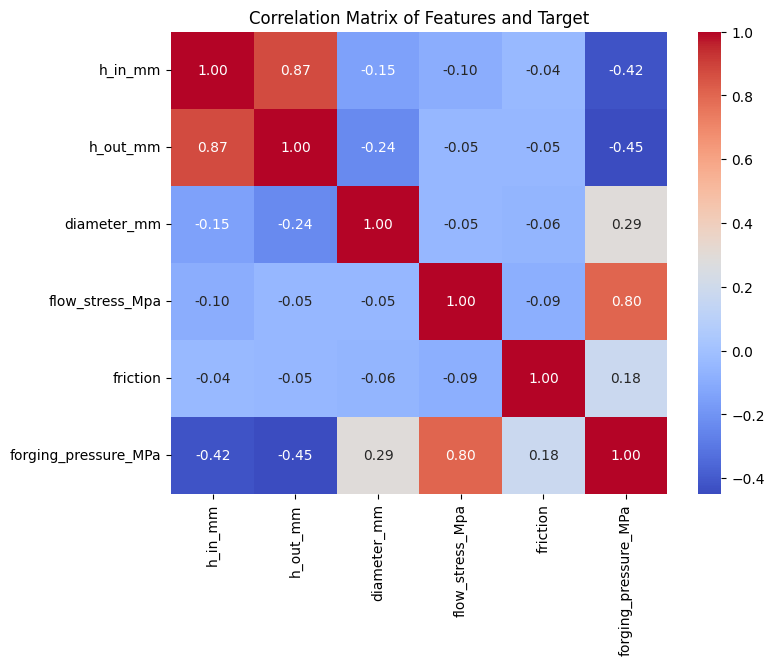

In [ ]:
X = data[['h_in_mm','h_out_mm','diameter_mm','flow_stress_Mpa','friction']]
y = data['forging_pressure_MPa']

# Calculate and display the correlation matrix
print('Correlation Matrix:')
print(data.corr())

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Target')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)
print (X_train)

    h_in_mm  h_out_mm  diameter_mm  flow_stress_Mpa  friction
55    75.42     50.98        68.02           207.40      0.20
88    67.01     34.51        63.21           266.60      0.24
26    71.36     38.57       103.06           167.29      0.23
42    64.11     33.20        86.69           154.91      0.23
69    49.75     24.96       108.86           259.79      0.17
..      ...       ...          ...              ...       ...
60    56.52     43.43        72.05           181.68      0.23
71    48.93     26.73        62.17           160.52      0.16
14    78.99     66.38        92.93           260.00      0.16
92    31.31     20.22        97.08           244.34      0.28
51    32.41     21.61        65.13           247.34      0.20

[80 rows x 5 columns]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
max_iter=2000, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
def evaluate(y_test, y_pred, model):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(model)
    print('RMSE:', rmse)
    print('R2 Score:', r2)
    print('---------------------')
evaluate(y_test, y_pred_mlp, 'MLP Regressor')

MLP Regressor
RMSE: 19.610920602554632
R2 Score: 0.9049202184182976
---------------------


In [ ]:
def evaluate(y_test, y_pred, model):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(model)
    print('RMSE:', rmse)
    print('R2 Score:', r2)
    print('---------------------')

In [ ]:
evaluate(y_test, y_pred_lr, 'Linear Regression')
# evaluate(y_test, y_pred_rf, 'Random Forest')
# evaluate(y_test, y_pred_svr, 'SVR')
evaluate(y_test, y_pred_mlp, 'MLP Regressor')

Linear Regression
RMSE: 10.875662960424249
R2 Score: 0.9707582275623218
---------------------
MLP Regressor
RMSE: 19.610920602554632
R2 Score: 0.9049202184182976
---------------------


In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
mlp, X_test_scaled, y_test,
n_repeats=20,
random_state=0
)

importance = result.importances_mean
features = X.columns
# Predict Rolling Force for New Machining Parameters
# Example input: [ ho, hf, w, r, σ]
new_sample = [[44.43,30.82,95.24,267.9, 0.25]]
new_sample_scaled = scaler.transform(new_sample)
prediction = mlp.predict(new_sample_scaled)
print('forging_presure',prediction[0])

forging_presure 420.5119155931017


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


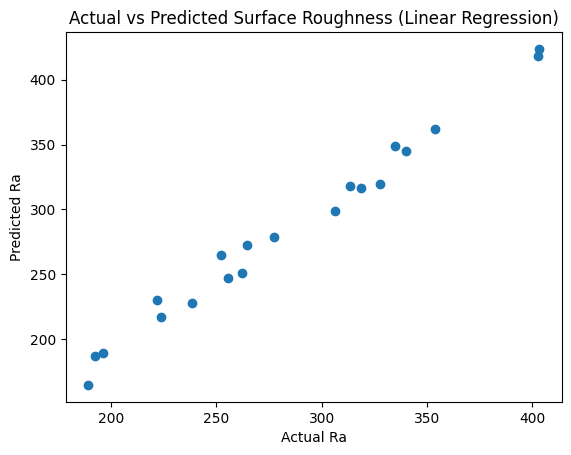

In [ ]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel('Actual Ra')
plt.ylabel('Predicted Ra')
plt.title('Actual vs Predicted Surface Roughness (Linear Regression)')
plt.show()